Sakshi Jha 00211192024 MDA Group - H

**Experiment 5:**

**AIM**

Empirically verify Zipf's Law and Heaps' Law on a real text corpus.

**Objectives**
- To analyze the frequency of words in a text corpus.
- To test Zipf's Law through a log-log graph.
- To understand the correlation between the size of corpus and vocabulary size.
- To test Heaps' Law through a log-log graph.

**Requirements**
- NLTK
- Collections (Counter)
- Matplotlib
- NumPy

**Theory**
Zipf's Law says that some words occur very often, but most of the words occur rarely. It says that the frequency of occurrence of a word is inversely proportional to its rank.

Heaps' Law gives a mathematical equation for the growth of vocabulary size in relation to the text corpus size.



Select a real text corpus for this experiment using NLTK Gutenberg corpus:- It conatin real books and is suitable for both Zipf's and Heaps' Law.  

In [1]:
import nltk
from nltk.corpus import gutenberg

nltk.download("gutenberg")

print("Number of documents:", len(gutenberg.fileids()))
print("Documents:")
print(gutenberg.fileids())

Number of documents: 18
Documents:
['austen-emma.txt', 'austen-persuasion.txt', 'austen-sense.txt', 'bible-kjv.txt', 'blake-poems.txt', 'bryant-stories.txt', 'burgess-busterbrown.txt', 'carroll-alice.txt', 'chesterton-ball.txt', 'chesterton-brown.txt', 'chesterton-thursday.txt', 'edgeworth-parents.txt', 'melville-moby_dick.txt', 'milton-paradise.txt', 'shakespeare-caesar.txt', 'shakespeare-hamlet.txt', 'shakespeare-macbeth.txt', 'whitman-leaves.txt']


[nltk_data] Downloading package gutenberg to /root/nltk_data...
[nltk_data]   Package gutenberg is already up-to-date!


18 real notebook/document in nltk Gutenberg corpus.

In [2]:
# check corpus size
words = []

for fileid in gutenberg.fileids():
    words.extend(gutenberg.words(fileid))

print("Number of documents:", len(gutenberg.fileids()))
print("Total number of words:", len(words))
print("First 20 words:", words[:20])

Number of documents: 18
Total number of words: 2621613
First 20 words: ['[', 'Emma', 'by', 'Jane', 'Austen', '1816', ']', 'VOLUME', 'I', 'CHAPTER', 'I', 'Emma', 'Woodhouse', ',', 'handsome', ',', 'clever', ',', 'and', 'rich']


2,621,613 total tokens/words returned by NLTK.

**gutenberg.words()** it includes punctuation and some header/title tokens So, first clean token before calculating words.


In [3]:
# Preparing the Text
import re

clean_words = [
    word.lower()
    for word in words
    if re.fullmatch(r"[a-zA-Z]+", word)
]

print("Total words after cleaning:", len(clean_words))
print("First 20 cleaned words:", clean_words[:20])

Total words after cleaning: 2135393
First 20 cleaned words: ['emma', 'by', 'jane', 'austen', 'volume', 'i', 'chapter', 'i', 'emma', 'woodhouse', 'handsome', 'clever', 'and', 'rich', 'with', 'a', 'comfortable', 'home', 'and', 'happy']


2,135,393 alphabetic words remain after cleaning.

Word frequency and Rank: It means frequency of each word in the corpus is counted. The words are then arranged from highest to lowest frequency and assigned a rank.

In [4]:
from collections import Counter

word_counts = Counter(clean_words)

ranked_words = word_counts.most_common()

print("Number of unique words:", len(ranked_words))
print("\nTop 10 most frequent words:")

for rank, (word, frequency) in enumerate(ranked_words[:10], start=1):
    print(rank, word, frequency)

Number of unique words: 41481

Top 10 most frequent words:
1 the 133583
2 and 95442
3 of 71267
4 to 48057
5 a 33960
6 in 33580
7 i 30265
8 that 28798
9 he 25857
10 it 22303


As the results show:

most frequent word- the(133,583)

second and(95,442)

third of (71.267)

This already shows that basic human pattern expected by Zipf's Law: a small number of words occur very frequently, while many words occur much less often.

**Zipf's Law**
A log-log plot is made for the ranks of words and the frequency of the words. As per Zipf’s Law, the graph should be a straight line sloping down.


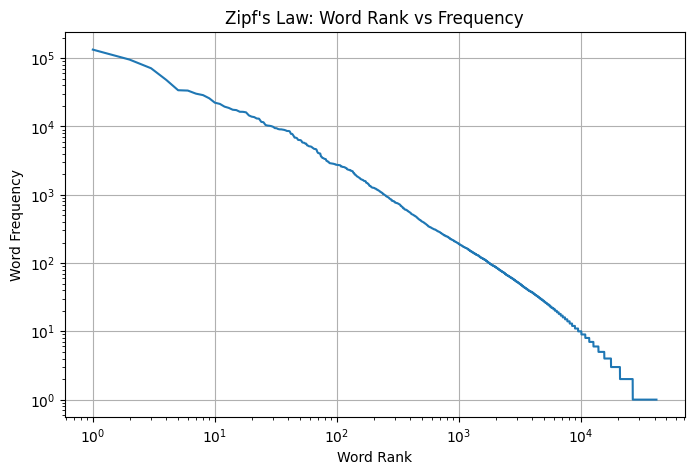

In [5]:
import numpy as np
import matplotlib.pyplot as plt

ranks = np.arange(1, len(ranked_words) + 1)
frequencies = np.array([freq for word, freq in ranked_words])

plt.figure(figsize=(8, 5))
plt.loglog(ranks, frequencies)

plt.xlabel("Word Rank")
plt.ylabel("Word Frequency")
plt.title("Zipf's Law: Word Rank vs Frequency")
plt.grid(True)
plt.show()

Graph shows the expected decreasing pattern on log-log scale means high frequency words have low rank, and frequency decreases as rank increases. This supports Zipf's Law

In [6]:
# Use the top 1000 words for a clearer approximate fit
fit_ranks = ranks[:1000]
fit_frequencies = frequencies[:1000]

log_ranks = np.log10(fit_ranks)
log_frequencies = np.log10(fit_frequencies)

slope, intercept = np.polyfit(log_ranks, log_frequencies, 1)

predicted_log = slope * log_ranks + intercept
fitted_frequencies = 10 ** predicted_log

r2 = 1 - np.sum((log_frequencies - predicted_log) ** 2) / np.sum(
    (log_frequencies - np.mean(log_frequencies)) ** 2
)

print("Zipf slope:", round(slope, 4))
print("R² value:", round(r2, 4))
print("Approximate relation:")
print(f"Frequency ≈ {10**intercept:.2f} × Rank^({slope:.2f})")

Zipf slope: -1.1171
R² value: 0.9932
Approximate relation:
Frequency ≈ 436014.50 × Rank^(-1.12)


Zipf slope = -1.1171 -> close to the expected inverse relationship (around -1).
R² = 0.9932 -> very strong linear fit on the log-log scale.
Relation: Frequency ≈ 436014.50 × Rank^(-1.12)

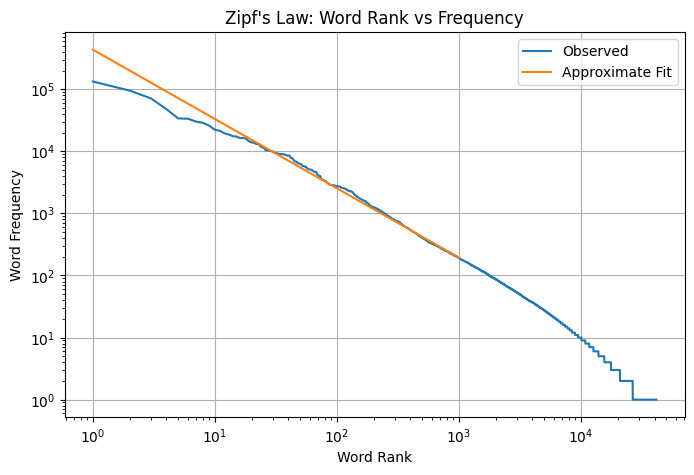

In [7]:
plt.figure(figsize=(8, 5))

plt.loglog(ranks, frequencies, label="Observed")
plt.loglog(fit_ranks, fitted_frequencies, label="Approximate Fit")

plt.xlabel("Word Rank")
plt.ylabel("Word Frequency")
plt.title("Zipf's Law: Word Rank vs Frequency")
plt.grid(True)
plt.legend()
plt.show()

Zipf section has both the actual data and the fitted line.

**Heaps’ Law**

Corpus size is progressively increased, while the vocabulary size is computed at every stage. Then the relationship between the two is depicted on a log-log scale.

In [8]:
corpus_sizes = [
    10000, 25000, 50000, 100000, 250000,
    500000, 1000000, 1500000, 2000000, len(clean_words)
]

vocab_sizes = []

for size in corpus_sizes:
    vocabulary = len(set(clean_words[:size]))
    vocab_sizes.append(vocabulary)

print("Corpus Size -> Vocabulary Size:")

for size, vocab in zip(corpus_sizes, vocab_sizes):
    print(size, "=", vocab)

Corpus Size -> Vocabulary Size:
10000 = 1762
25000 = 2882
50000 = 4176
100000 = 5734
250000 = 8892
500000 = 12650
1000000 = 17671
1500000 = 26065
2000000 = 38194
2135393 = 41481


Results show: The corpus size increases, vocabulary size also increases, but more slowly than corpus size.



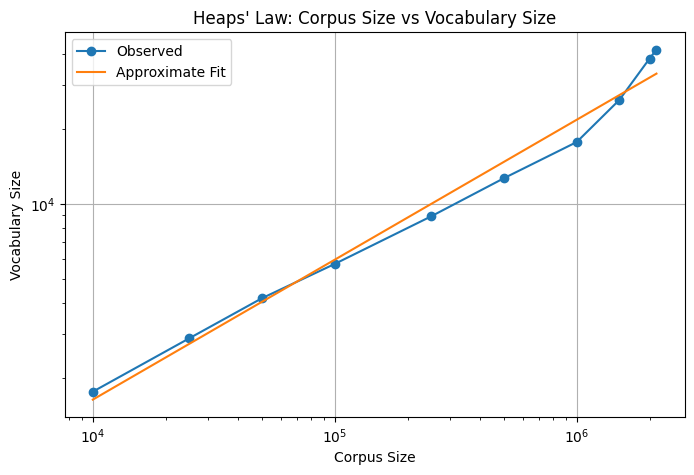

Heaps' slope (β): 0.5613
R² value: 0.9841
Approximate relation: Vocabulary ≈ 9.31 × Corpus Size^(0.56)


In [9]:
log_corpus = np.log10(corpus_sizes)
log_vocab = np.log10(vocab_sizes)

slope_heaps, intercept_heaps = np.polyfit(
    log_corpus, log_vocab, 1
)

fitted_vocab = 10 ** (
    intercept_heaps + slope_heaps * log_corpus
)

r2_heaps = 1 - np.sum(
    (log_vocab - (slope_heaps * log_corpus + intercept_heaps)) ** 2
) / np.sum(
    (log_vocab - np.mean(log_vocab)) ** 2
)

plt.figure(figsize=(8, 5))

plt.loglog(
    corpus_sizes,
    vocab_sizes,
    marker="o",
    label="Observed"
)

plt.loglog(
    corpus_sizes,
    fitted_vocab,
    label="Approximate Fit"
)

plt.xlabel("Corpus Size")
plt.ylabel("Vocabulary Size")
plt.title("Heaps' Law: Corpus Size vs Vocabulary Size")
plt.grid(True)
plt.legend()
plt.show()

print("Heaps' slope (β):", round(slope_heaps, 4))
print("R² value:", round(r2_heaps, 4))
print(
    f"Approximate relation: "
    f"Vocabulary ≈ {10**intercept_heaps:.2f} × "
    f"Corpus Size^({slope_heaps:.2f})"
)

β = 0.5613 -> shows vocabulary grows sub-linearly with corpus size.
R² = 0.9841 -> very good fit.
Relation: Vocabulary ≈ 9.31 × Corpus Size^0.56

### **Observation**

- Word frequency reduced with an increase in word rank in accordance with the expected observation from Zipf's Law.
- Slope of Zipf's Law was -1.1171 with R²=0.9932 indicating strong approximate conformity to Zipf's Law.
- There was an increase in vocabulary size with an increase in corpus size but with a slower growth rate.
- The value of β for Heaps' Law was 0.5613 with R²=0.9841.

### **Result**

Zipf's Law and Heaps' Law have been successfully validated through the NLTK Gutenberg text corpus. Log-log plot along with the approximation of the value confirmed that the actual corpus conforms to the statistical laws.

### **Learning Outcome**

We learned about the relationship between word frequency and word rank as well as between the vocabulary size and corpus size. We also learned to plot log-log plots and approximate values for these relationships.